In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of FruitinAmazon.zip" /content/

In [ ]:
!ls /content/

'Copy of FruitinAmazon.zip'   dataset   drive   sample_data


In [ ]:
!unzip -o "/content/Copy of FruitinAmazon.zip" -d /content/dataset

Archive:  /content/Copy of FruitinAmazon.zip
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/dataset/FruitinAmazon/tes

In [ ]:
os.listdir("/content/dataset/FruitinAmazon")

['test', 'train']

In [ ]:
train_dir = "/content/dataset/FruitinAmazon/train"

### Checking for Corrupted Images

In [ ]:
class_names = sorted(os.listdir(train_dir))

print(class_names)

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


### Checking Class Distribution

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("="*40)
for k, v in class_counts.items():
    print(f"{k:<20} {v}")
print("="*40)


Class Distribution:
acai                 15
cupuacu              15
graviola             15
guarana              15
pupunha              15
tucuma               15


### Visualizing Random Images

In [ ]:
import random

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

## Data Generation

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


### Visualizing Training Dataset

In [ ]:
import matplotlib.pyplot as plt

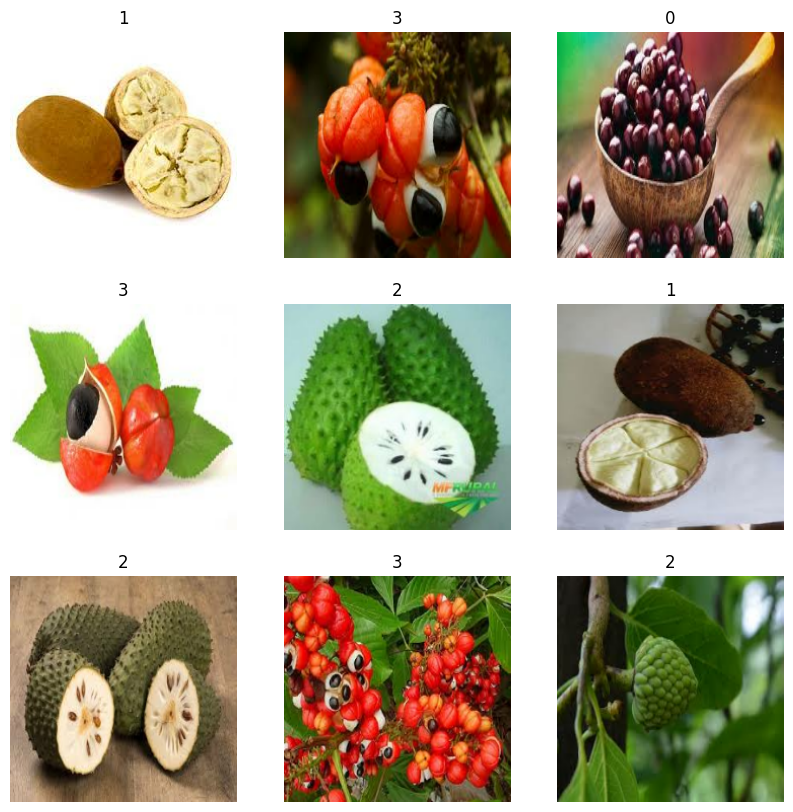

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## Data Augmentation


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

### Visualizing Augmented Images

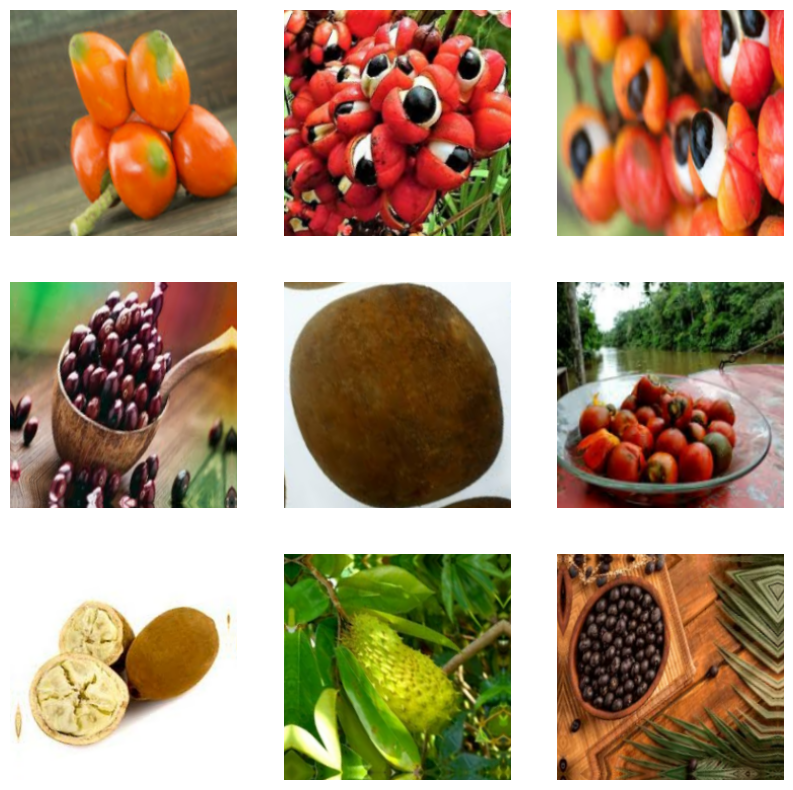

In [ ]:
plt.figure(figsize=(10,10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

## CNN Model with Batch Normalization and Dropout

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

### Compiling the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.2500 - loss: 2.1575 - val_accuracy: 0.1111 - val_loss: 2.6219
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.6528 - loss: 1.0455 - val_accuracy: 0.0556 - val_loss: 2.1081
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5972 - loss: 1.0974 - val_accuracy: 0.0556 - val_loss: 1.9397
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.6528 - loss: 1.0084 - val_accuracy: 0.0556 - val_loss: 1.9198
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.7222 - loss: 0.9246 - val_accuracy: 0.1667 - val_loss: 1.9787
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7361 - loss: 0.8163 - val_accuracy: 0.2222 - val_loss: 2.0564
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.7361 - loss: 0.7792 - val_accuracy: 0.2222 - val_loss: 2.1148
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.8056 - loss: 0.7272 - val_accuracy: 0.2222 - val_loss: 2.1413
Epoch 9/

### Evaluating Model

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step - accuracy: 0.2222 - loss: 2.2228
Validation Accuracy: 0.2222222238779068


 Transfer Learning using VGG16

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Freezing Pre-trained Layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

### Adding Custom Classification Layers

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

### Compiling the Model

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.3194 - loss: 6.3056 - val_accuracy: 0.3889 - val_loss: 10.9576
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.8056 - loss: 6.3423 - val_accuracy: 0.4444 - val_loss: 8.3503
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 16s/step - accuracy: 0.8333 - loss: 2.8161 - val_accuracy: 0.6111 - val_loss: 2.5447
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 21s/step - accuracy: 0.9722 - loss: 0.2621 - val_accuracy: 0.4444 - val_loss: 5.9812
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 17s/step - accuracy: 0.9306 - loss: 0.2346 - val_accuracy: 0.5000 - val_loss: 6.1886
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 16s/step - accuracy: 0.9861 - loss: 0.0435 - val_accuracy: 0.5556 - val_loss: 6.1821
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 21s/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 0.5556 - val_loss: 5.9765
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.5556 - val_loss: 5.7800

### Evaluating Model

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5556 - loss: 5.6177
Validation Accuracy: 0.5555555820465088


### Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.57      1.00      0.73         4
    graviola       0.50      1.00      0.67         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.50      0.75      0.60         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.56        18
   macro avg       0.43      0.53      0.43        18
weighted avg       0.54      0.56      0.49        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Inference Output

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


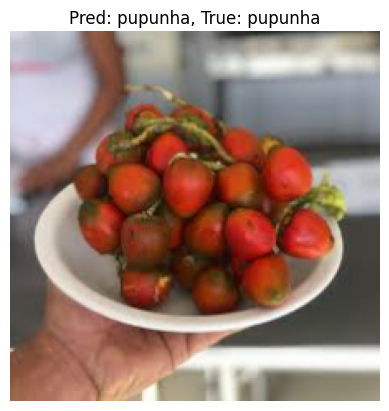

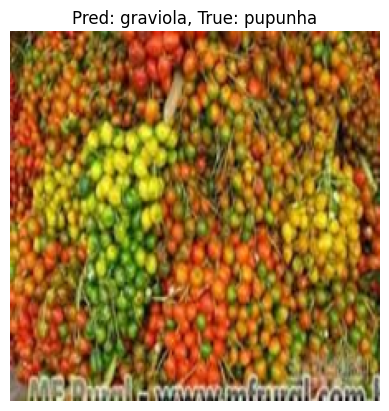

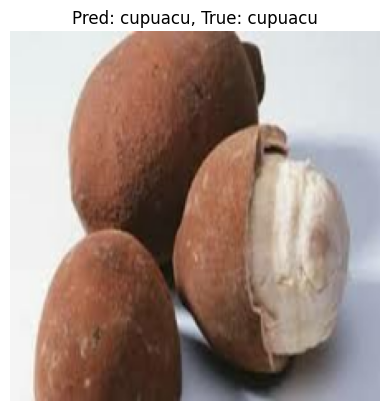

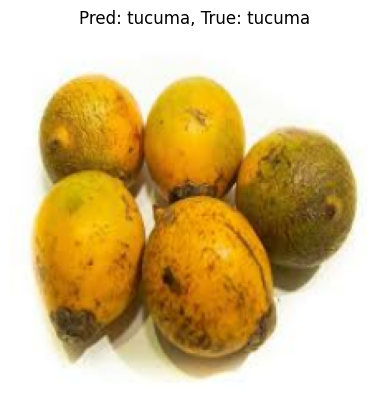

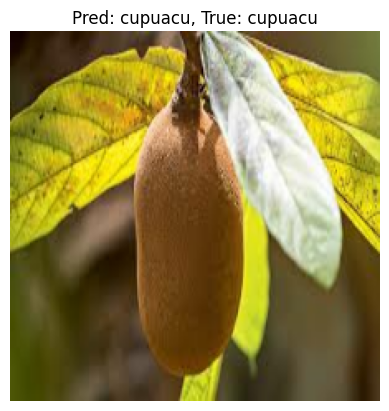

In [ ]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_label = class_names[np.argmax(preds[i])]
        true_label = class_names[labels[i]]

        plt.title(f"Pred: {pred_label}, True: {true_label}")
        plt.axis("off")
        plt.show()